# Elastic Net HDB Resale Model Notebook

This notebook made to:

- show the output step by step
- clearly document how the Elastic Net model was tuned
- report both log-scale and back-transformed price metrics

**Expected file in the same folder:** `hdb_with_amenities_macro.csv`


## 1. Imports

I first import the libraries used for data handling, feature engineering, model fitting, and evaluation.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import os
os.chdir("C:/Users/hai liang/Downloads/acro")

Matplotlib is building the font cache; this may take a moment.


## 2. Load data and match the OLS sample

This section reproduces the same sample restrictions used in the OLS specification, so the Elastic Net results are directly comparable.

The main cleaning choices are:

- drop rows with missing values
- remove rare flat types (`1 ROOM`, `MULTI-GENERATION`)
- remove observations from year 2020
- create the target variable `log_resale_price_real`
- create `num_primary_1km`


In [2]:
df_raw = pd.read_csv("hdb_with_amenities_macro.csv")
print(f"Initial shape: {df_raw.shape}")

df = df_raw.dropna().copy()
print(f"After dropping nulls: {df.shape}")

df = df[~df["flat_type"].isin(["1 ROOM", "MULTI-GENERATION"])].copy()
print(f"After dropping 1 ROOM and MULTI-GENERATION: {df.shape}")

df["year_temp"] = pd.to_datetime(df["month"], errors="coerce").dt.year
df = df[df["year_temp"] != 2020].drop(columns="year_temp").copy()
print(f"After dropping 2020: {df.shape}")

df["log_resale_price_real"] = np.log(df["resale_price_real"])

df["num_primary_1km"] = df["primary_schools_1km"].apply(
    lambda x: len(x.split("|")) if pd.notna(x) and x != "" else 0
)

df.head()

Initial shape: (157821, 37)
After dropping nulls: (114147, 37)
After dropping 1 ROOM and MULTI-GENERATION: (114057, 37)
After dropping 2020: (96796, 37)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,dist_nearest_park_m,parks_1km,dist_nearest_sportsg_m,nearest_sportsg_name,dist_nearest_mall_m,nearest_mall_name,dist_nearest_healthcare_m,nearest_healthcare_name,log_resale_price_real,num_primary_1km
23333,2021-01-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,64 years 01 month,...,372.1,GELENGGANG PARK|LEBAN PARK|YIO CHU KANG GARDEN...,925.7,ActiveSG Gym@Ang Mo Kio Community Centre,1083.8,Broadway Plaza,1028.5,Ang Mo Kio Polyclinic,12.618536,2
23334,2021-01-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,07 TO 09,45.0,Improved,1986,64 years 01 month,...,372.1,GELENGGANG PARK|LEBAN PARK|YIO CHU KANG GARDEN...,925.7,ActiveSG Gym@Ang Mo Kio Community Centre,1083.8,Broadway Plaza,1028.5,Ang Mo Kio Polyclinic,12.682778,2
23335,2021-01-01,ANG MO KIO,3 ROOM,331,ANG MO KIO AVE 1,04 TO 06,68.0,New Generation,1981,59 years,...,275.5,ANG MO KIO TOWN GARDEN EAST|BISHAN-ANG MO KIO ...,180.2,Ang Mo Kio Swimming Complex,858.7,Ang Mo Kio Hub,1471.1,Ang Mo Kio Polyclinic,12.827360,2
23336,2021-01-01,ANG MO KIO,3 ROOM,534,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,58 years 02 months,...,580.2,ANG MO KIO TOWN GARDEN EAST,1296.5,Ang Mo Kio Swimming Complex,754.5,Jubilee Square,944.3,Ang Mo Kio Polyclinic,12.846408,2
23337,2021-01-01,ANG MO KIO,3 ROOM,561,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,1980,58 years 01 month,...,720.3,ANG MO KIO TOWN GARDEN EAST|TAVISTOCK AVE PK|H...,1217.7,Ang Mo Kio Swimming Complex,1011.5,myVillage,1416.3,Ang Mo Kio Polyclinic,12.846408,2


## 3. Feature engineering

This follows the same engineering logic as the OLS version.

### Variables created
- `remaining_lease_years`: parsed from the text field `remaining_lease`
- `floor_lower`: lower bound of the storey range
- `floor_category`: grouped floor levels
  - `Low`: 1 to 5
  - `Mid`: 6 to 12
  - `High`: 13 and above
- `year`: extracted from `month` for stratified splitting


In [3]:
def parse_remaining_lease(s):
    match = re.match(r"(\d+) years?(?: (\d+) months?)?", str(s))
    if match:
        years = int(match.group(1))
        months = int(match.group(2)) if match.group(2) else 0
        return round(years + months / 12, 2)
    return np.nan

df["remaining_lease_years"] = df["remaining_lease"].apply(parse_remaining_lease)

df["floor_lower"] = df["storey_range"].str.extract(r"^(\d+)").astype(int)
df["floor_category"] = pd.cut(
    df["floor_lower"],
    bins=[0, 5, 12, float("inf")],
    labels=["Low", "Mid", "High"],
    right=True
)

df["year"] = pd.to_datetime(df["month"], errors="coerce").dt.year

target = "log_resale_price_real"

df[["remaining_lease", "remaining_lease_years", "storey_range", "floor_lower", "floor_category"]].head(10)

,remaining_lease,remaining_lease_years,storey_range,floor_lower,floor_category
23333,64 years 01 month,64.08,01 TO 03,1,Low
23334,64 years 01 month,64.08,07 TO 09,7,Mid
23335,59 years,59.00,04 TO 06,4,Low
23336,58 years 02 months,58.17,04 TO 06,4,Low
23337,58 years 01 month,58.08,01 TO 03,1,Low
23338,64 years 02 months,64.17,07 TO 09,7,Mid
23339,58 years 02 months,58.17,04 TO 06,4,Low
23340,59 years 01 month,59.08,04 TO 06,4,Low
23341,64 years,64.00,07 TO 09,7,Mid
23342,54 years 04 months,54.33,04 TO 06,4,Low


## 4. Stratified train-test split

To stay consistent with the OLS benchmark, the split is stratified by:

`town + flat_type + year`

Rows belonging to a `strat_key` that appears only once are removed first, because stratified splitting requires at least 2 observations in a stratum.


In [4]:
df["strat_key"] = (
    df["town"].astype(str) + "_" +
    df["flat_type"].astype(str) + "_" +
    df["year"].astype(str)
)

strat_counts = df["strat_key"].value_counts()
valid_keys = strat_counts[strat_counts >= 2].index
n_before = len(df)

df = df[df["strat_key"].isin(valid_keys)].copy()
print(f"Dropped {n_before - len(df)} rows with singleton strat_key combinations. Remaining: {len(df):,}")

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["strat_key"]
)

print(f"Train size: {len(train_df):,} | Test size: {len(test_df):,}")

Dropped 7 rows with singleton strat_key combinations. Remaining: 96,789
Train size: 77,431 | Test size: 19,358


## 5. Define features

### Continuous features
These are scaled using `StandardScaler` so that all variables are on a comparable scale before Elastic Net is fitted. This is important because Elastic Net penalizes coefficient sizes, and without scaling, variables with different numeric ranges would be penalized unfairly.

### Categorical features
These are one-hot encoded using `pd.get_dummies()`so they can be represented numerically in the regression model.

We also manually drop the same reference categories as in the OLS setup, so the design matrix is aligned with that interpretation.


In [5]:
continuous_features = [
    "remaining_lease_years",
    "nearest_train_dist_m",
    "dist_nearest_hawker_m",
    "dist_nearest_primary_m",
    "num_primary_1km",
    "dist_nearest_park_m",
    "dist_nearest_sportsg_m",
    "dist_nearest_mall_m",
    "dist_nearest_healthcare_m",
]

categorical_features = ["flat_type", "town", "floor_category"]

reference_categories = {
    "flat_type": "2 ROOM",
    "town": "ANG MO KIO",
    "floor_category": "Low"
}

print("Continuous features:", continuous_features)
print("Categorical features:", categorical_features)
print("Reference categories:", reference_categories)

Continuous features: ['remaining_lease_years', 'nearest_train_dist_m', 'dist_nearest_hawker_m', 'dist_nearest_primary_m', 'num_primary_1km', 'dist_nearest_park_m', 'dist_nearest_sportsg_m', 'dist_nearest_mall_m', 'dist_nearest_healthcare_m']
Categorical features: ['flat_type', 'town', 'floor_category']
Reference categories: {'flat_type': '2 ROOM', 'town': 'ANG MO KIO', 'floor_category': 'Low'}


## 6. One-hot encoding and scaling

This section:

1. one-hot encodes the categorical variables
2. drops the chosen reference categories
3. scales continuous features on the **training set only**
4. combines scaled continuous variables and dummy variables
5. aligns the test columns with the training columns


In [6]:
train_encoded = pd.get_dummies(train_df, columns=categorical_features, drop_first=False)
test_encoded = pd.get_dummies(test_df, columns=categorical_features, drop_first=False)

ref_cols = [f"{col}_{ref}" for col, ref in reference_categories.items()]
print(f"Dropping reference columns: {ref_cols}")

train_encoded = train_encoded.drop(columns=ref_cols, errors="ignore")
test_encoded = test_encoded.drop(columns=ref_cols, errors="ignore")

dummy_cols = [
    c for c in train_encoded.columns
    if any(c.startswith(f"{f}_") for f in categorical_features)
]

scaler = StandardScaler()

train_cont = pd.DataFrame(
    scaler.fit_transform(train_encoded[continuous_features]),
    columns=continuous_features,
    index=train_encoded.index
)

test_cont = pd.DataFrame(
    scaler.transform(test_encoded[continuous_features]),
    columns=continuous_features,
    index=test_encoded.index
)

X_train = pd.concat([train_cont, train_encoded[dummy_cols].astype(int)], axis=1)
X_test = pd.concat([test_cont, test_encoded[dummy_cols].astype(int)], axis=1)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df[target]
y_test = test_df[target]

y_train_actual = train_df["resale_price_real"]
y_test_actual = test_df["resale_price_real"]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"Number of dummy columns: {len(dummy_cols)}")

X_train.head()

Dropping reference columns: ['flat_type_2 ROOM', 'town_ANG MO KIO', 'floor_category_Low']
X_train shape: (77431, 40)
X_test shape : (19358, 40)
Number of dummy columns: 31


,remaining_lease_years,nearest_train_dist_m,dist_nearest_hawker_m,dist_nearest_primary_m,num_primary_1km,dist_nearest_park_m,dist_nearest_sportsg_m,dist_nearest_mall_m,dist_nearest_healthcare_m,flat_type_3 ROOM,...,town_QUEENSTOWN,town_SEMBAWANG,town_SENGKANG,town_SERANGOON,town_TAMPINES,town_TOA PAYOH,town_WOODLANDS,town_YISHUN,floor_category_Mid,floor_category_High
37879,-0.596201,-0.132170,-0.303619,-0.392227,-1.436755,-0.487759,0.824188,1.230686,0.023207,0,...,0,0,0,0,0,0,0,0,1,0
139504,-0.355614,-0.476119,1.705066,1.082625,0.007161,0.935964,-0.016370,-0.436999,0.239815,0,...,0,0,0,0,0,0,0,0,1,0
58509,1.313754,0.206389,1.652283,-1.388523,0.007161,0.526024,-0.150982,0.593245,-1.435772,0,...,0,0,0,0,0,0,0,0,0,0
114127,1.470571,0.413406,0.061819,1.566569,0.007161,-0.563018,0.252562,-1.722219,-0.917989,0,...,0,0,0,0,0,0,0,0,1,0
81653,-0.299991,-0.113840,-0.046930,1.175691,-1.436755,-0.530258,-1.368806,-0.018355,1.953457,0,...,0,0,0,0,0,0,0,0,0,0


## 7. Model tuning: Elastic Net CV

This is the key section for explaining **how the model was tuned**.

Elastic Net has two main tuning parameters:

- **alpha**: controls overall penalty strength  
  - larger `alpha` means stronger shrinkage
  - smaller `alpha` means weaker shrinkage

- **l1_ratio**: controls the mix between Lasso and Ridge  
  - `l1_ratio = 1.0` is pure Lasso
  - values closer to 0 behave more like Ridge
  - values close to 1 give sparse solutions while stabilizing coefficients

### Why this tuning grid?
Based on earlier tuning results, the best region was near:

- `alpha ≈ 1e-05`
- `l1_ratio ≈ 0.95`

So instead of searching a huge space, the grid was refined around that neighborhood:

- `l1_ratio = [0.95, 0.98, 1.0]`
- `alpha = logspace(1e-5 to 1e-3, 25 values)`

### Cross-validation
`ElasticNetCV` uses 5-fold cross-validation on the training set to choose the best hyperparameters based on predictive performance.


In [7]:
elastic_net = ElasticNetCV(
    l1_ratio=[0.95, 0.98, 1.0],
    alphas=np.logspace(-5, -3, 25),
    cv=5,
    random_state=42,
    max_iter=50000,
    tol=1e-3,
    n_jobs=-1,
)

elastic_net.fit(X_train, y_train)

print("===== ELASTIC NET TUNING SUMMARY =====")
print("Best alpha   :", elastic_net.alpha_)
print("Best l1_ratio:", elastic_net.l1_ratio_)

===== ELASTIC NET TUNING SUMMARY =====
Best alpha   : 1e-05
Best l1_ratio: 0.95


## 8. Visualise the tuning results

The plot below helps explain tuning.

It shows the mean cross-validation error across different `alpha` values for each candidate `l1_ratio`.

Interpretation:
- lower values are better
- the chosen `alpha` is where CV error is minimized for the selected `l1_ratio`


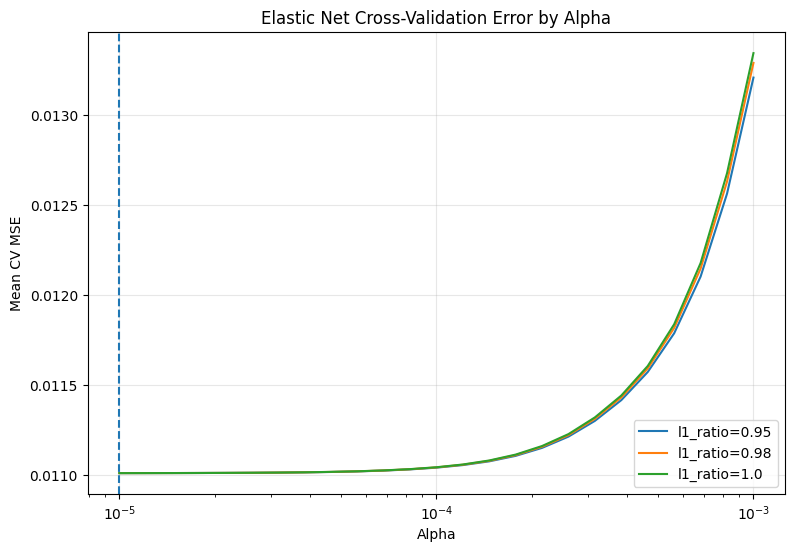

In [8]:
mean_mse = elastic_net.mse_path_.mean(axis=2)

plt.figure(figsize=(9, 6))
for i, l1 in enumerate(elastic_net.l1_ratio):
    plt.semilogx(elastic_net.alphas_, mean_mse[i], label=f"l1_ratio={l1}")

plt.axvline(elastic_net.alpha_, linestyle="--")
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("Elastic Net Cross-Validation Error by Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Predictions

The model predicts on the **log price scale**, because the target is `log_resale_price_real`.

Then predictions are exponentiated back to the original SGD scale to make the results easier to interpret.


In [9]:
y_pred_log = elastic_net.predict(X_test)
y_pred_actual = np.exp(y_pred_log)

pred_df = pd.DataFrame({
    "actual_log": y_test,
    "predicted_log": y_pred_log,
    "actual_price": y_test_actual,
    "predicted_price": y_pred_actual
})

pred_df.head(10)

,actual_log,predicted_log,actual_price,predicted_price
133984,12.936034,13.014317,415000.00,448793.010035
149133,12.898729,12.765734,399803.63,350015.788800
112037,13.351031,13.393908,628461.95,655994.385986
26490,12.743142,12.918709,342196.91,407872.174648
88536,13.349242,13.500752,627338.94,729964.862075
137320,13.740993,13.795012,928191.23,979710.391982
125793,13.161789,13.130102,520106.44,503884.272938
29280,13.235866,13.145534,560097.59,511720.475753
24227,13.318767,13.481969,608509.14,716382.381703
47458,13.019526,13.007032,451136.80,445535.286628


## 10. Evaluation metrics

We report two sets of metrics:

### On log scale
This is the most direct comparison to the OLS model since OLS also used `log_resale_price_real` as the dependent variable.

### On original price scale
This is more intuitive in dollar terms, because RMSE and MAE are in SGD.
This is after converting predictions back from log



In [16]:
# Lin-Lin loss with w = 2
def linlin_loss(y_true, y_pred, w=2):
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, w * np.abs(errors), np.abs(errors)))

r2_log = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
linlin_log = linlin_loss(y_test, y_pred_log, w=2)

r2_actual = r2_score(y_test_actual, y_pred_actual)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
linlin_actual = linlin_loss(y_test_actual, y_pred_actual, w=2)

metrics_df = pd.DataFrame({
    "scale": ["log_resale_price_real", "resale_price_real"],
    "R2": [r2_log, r2_actual],
    "RMSE": [rmse_log, rmse_actual],
    "LinLinLoss_w2": [linlin_log, linlin_actual]
})

print("===== ELASTIC NET RESULTS (MATCHED TO OLS SPEC) =====")
display(metrics_df)

===== ELASTIC NET RESULTS (MATCHED TO OLS SPEC) =====


,scale,R2,RMSE,LinLinLoss_w2
0,log_resale_price_real,0.885631,0.106118,0.120823
1,resale_price_real,0.874358,76379.508829,83371.395334


## 11. Coefficients

Elastic Net produces coefficients for each feature.

Because it includes regularisation:
- some coefficients may be shrunk strongly toward zero
- some may become exactly zero, especially when `l1_ratio` is close to 1

This is useful to explain that Elastic Net performs both:
- prediction
- variable selection / shrinkage


In [14]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": elastic_net.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

coef_df.head(20)

,feature,coefficient
12,flat_type_EXECUTIVE,1.081627
11,flat_type_5 ROOM,0.818876
10,flat_type_4 ROOM,0.616340
31,town_SEMBAWANG,-0.338805
32,town_SENGKANG,-0.317682
9,flat_type_3 ROOM,0.316326
27,town_MARINE PARADE,0.314168
25,town_JURONG WEST,-0.278952
20,town_CHOA CHU KANG,-0.271021
18,town_BUKIT TIMAH,0.260492
